# 장외파생상품 기초실무 과제 {.unnumbered}

In [1]:
import numpy as np
import scipy.stats as sst
import matplotlib.pyplot as plt
import pandas_market_calendars as mcal
from datetime import date

In [2]:
expiry = date(2026, 3, 16)
initial = date(2025, 4, 29)
nyse = mcal.get_calendar('NYSE')
calendardays = (expiry - initial).days
tradingdays = nyse.valid_days(start_date=initial, end_date=expiry)

print("Calendar days to expiry : ", calendardays)
print("Trading days to expriy : ",len(tradingdays))

Calendar days to expiry :  321
Trading days to expriy :  221


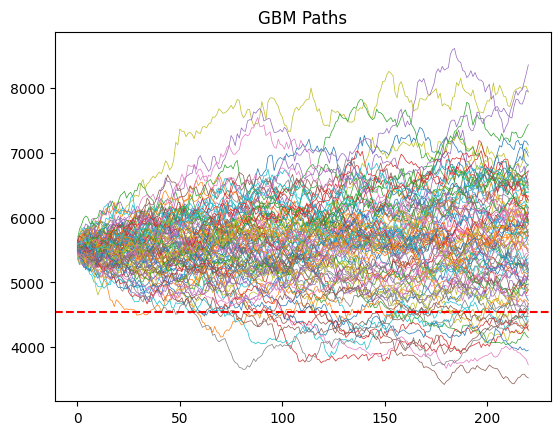

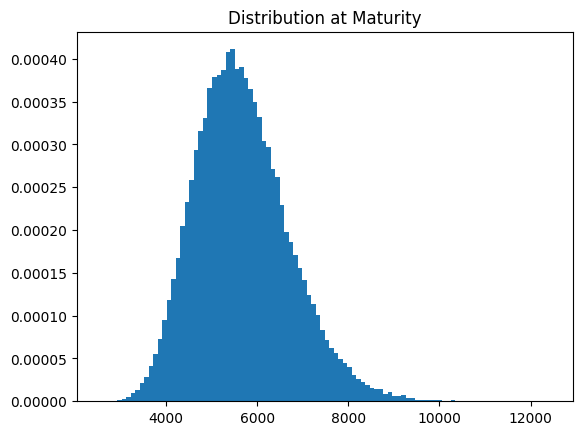

In [3]:
# Set parameter
s0 = 5675.29
s1 = 5527.8286 # Numerix model's spot price
barrier = 0.8 * s0
t = calendardays / 365
r = 0.03
q = 0
vol = 0.1926 # Numerix model's arithmetic average of volatilities
rebate = 0.06
timestep = len(tradingdays)
notional = 10000
num_mcs = 100000

# Set GBM paths
dt = t / timestep
z = np.random.randn(num_mcs, timestep)
gbm_return = (r - q - 0.5 * vol**2) * dt + vol * np.sqrt(dt) * z
gbm_paths = s1 * np.exp(np.cumsum(gbm_return, axis=1))

# Visualize paths
plt.figure()
plt.plot(gbm_paths[:100].T, lw=0.5)
plt.axhline(barrier, color='red', linestyle='--')
plt.title('GBM Paths')

plt.figure()
plt.hist(gbm_paths[:, -1], bins=100, density=True)
plt.title('Distribution at Maturity')
plt.show()

In [4]:
# Calculate Knock-out
knock_paths = gbm_paths[(gbm_paths < barrier).any(axis=1)]
non_knock_paths = gbm_paths[~(gbm_paths < barrier).any(axis=1)]
elb_ratio = len(knock_paths) / num_mcs

print("Number of Knock-out paths : ", len(knock_paths))
print("Probability of Knock-out : ", elb_ratio)

Number of Knock-out paths :  24252
Probability of Knock-out :  0.24252


In [5]:
# Calculate payoff & npv
total_rebate = rebate * notional * len(knock_paths)
total_optionvalue = np.maximum(1 - non_knock_paths[:, -1]/s0, 0).sum() * notional

elb_payoff = (total_rebate + total_optionvalue) / num_mcs
elb_price = elb_payoff * np.exp(-r * (t+3/365))

print("ELB pair price : ", elb_price)

ELB pair price :  373.1090737369608


In [6]:
nx_elb_price = 372.1711406
nx_elb_ratio = 0.2525